Epoch 1/100


C:\Users\david\miniconda3\envs\entornoML2024\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3662 - loss: 1.5593 - val_accuracy: 0.4509 - val_loss: 1.3592
Epoch 2/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4560 - loss: 1.3304 - val_accuracy: 0.4882 - val_loss: 1.2751
Epoch 3/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4988 - loss: 1.2536 - val_accuracy: 0.5046 - val_loss: 1.2411
Epoch 4/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5104 - loss: 1.2248 - val_accuracy: 0.5174 - val_loss: 1.2077
Epoch 5/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5308 - loss: 1.1816 - val_accuracy: 0.5267 - val_loss: 1.2014
Epoch 6/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5260 - loss: 1.1828 - val_accuracy: 0.5347 - val_loss: 1.1853
Epoch 7/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5460 - loss: 1.1397 - val_accuracy: 0.5351 - val_loss: 1.1601
Epoch 8/100
998/998 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5496 - loss: 1.1398 - val_accuracy: 0.5455

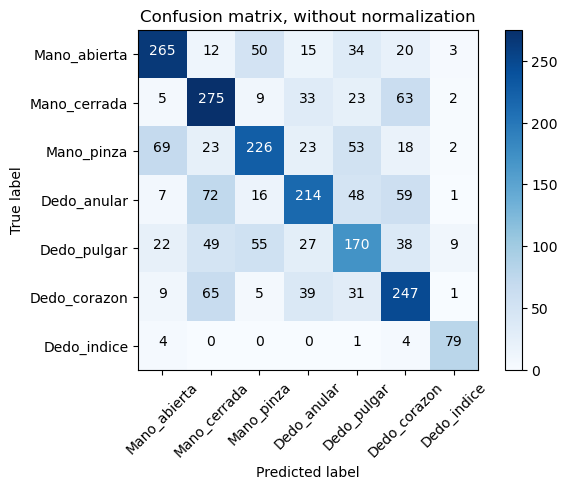

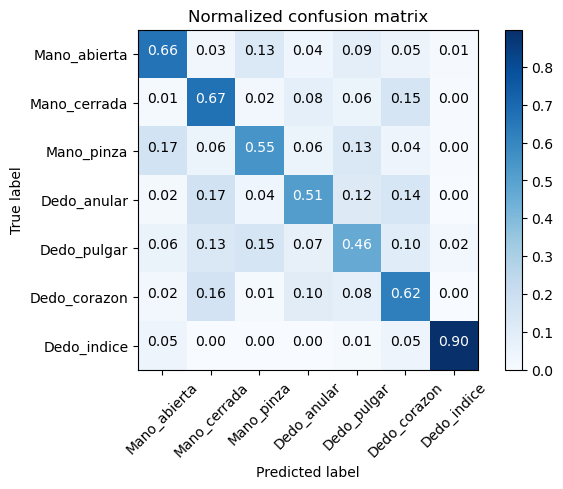

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import pickle

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_cerrada['Wav_Leng'], 
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_pulgar['Wav_Leng'], 
    df_corazon['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_cerrada['Dasdv'], 
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_pulgar['Dasdv'], 
    df_corazon['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_cerrada['Damv'], 
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_pulgar['Damv'], 
    df_corazon['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_cerrada['iav'], 
    df_pinza['iav'], 
    df_anular['iav'], 
    df_pulgar['iav'], 
    df_corazon['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Aplicar factores de escalamiento para ajustar la relevancia
scaling_factors = {
    "MAV_total": 1.0,
    "VAR_total": 1.0,
    "RMS_total": 1.0,
    "Wav_Leng": 1.0,
    "Dasdv": 1.0,
    "Damv": 1.0,
    "iav": 1.0
}

for feature, factor in scaling_factors.items():
    abs_df[feature] = abs_df[feature] * factor

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Guardar el StandardScaler ajustado
with open('standard_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# Convertir las etiquetas en formato one-hot encoding
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

# Crear el modelo de red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))

# Compilar el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test))

# Hacer predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluar el modelo
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_true, y_pred_classes)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# Guardar el modelo entrenado en formato nativo de Keras
model.save('modelo_red_neuronal.keras')


Epoch 1/100


C:\Users\david\miniconda3\envs\entornoML2024\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3107 - loss: 1.6724 - val_accuracy: 0.5343 - val_loss: 1.2153
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5336 - loss: 1.1996 - val_accuracy: 0.5672 - val_loss: 1.0688
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5972 - loss: 1.0244 - val_accuracy: 0.5612 - val_loss: 1.0311
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5882 - loss: 0.9794 - val_accuracy: 0.5313 - val_loss: 0.9793
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5940 - loss: 0.9387 - val_accuracy: 0.5761 - val_loss: 0.9562
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6226 - loss: 0.9247 - val_accuracy: 0.5701 - val_loss: 0.9721
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6259 - loss: 0.9185 - val_accuracy: 0.5791 - val_loss: 0.9563
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6022 - loss: 0.8991 - val_accuracy: 0.5881

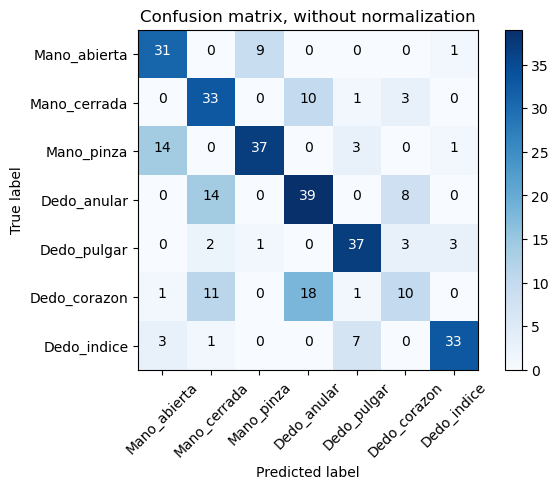

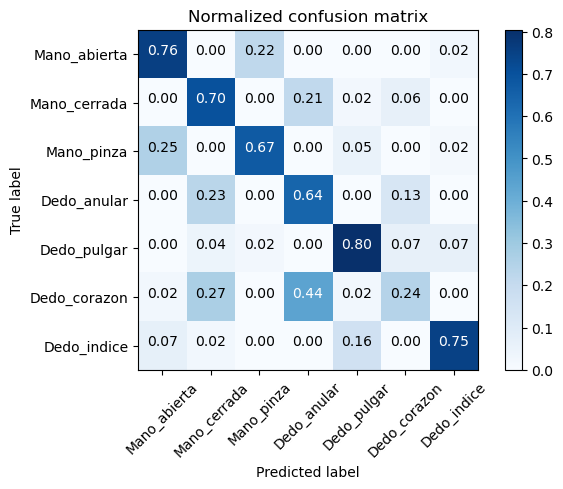

In [10]:
import pandas as pd*
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZADAVID.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADADAVID.csv")
df_anular = pd.read_csv("DATASETTOMAANULARDAVID.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGARDAVID.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZONDAVID.csv")
df_indice = pd.read_csv("DATASETTOMAINDICEDAVID.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTADAVID.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_cerrada['Wav_Leng'], 
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_pulgar['Wav_Leng'], 
    df_corazon['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_cerrada['Dasdv'], 
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_pulgar['Dasdv'], 
    df_corazon['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_cerrada['Damv'], 
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_pulgar['Damv'], 
    df_corazon['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_cerrada['iav'], 
    df_pinza['iav'], 
    df_anular['iav'], 
    df_pulgar['iav'], 
    df_corazon['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Aplicar factores de escalamiento para ajustar la relevancia
scaling_factors = {
    "MAV_total": 1.0,
    "VAR_total": 1.0,
    "RMS_total": 1.0,
    "Wav_Leng": 1.0,
    "Dasdv": 1.0,
    "Damv": 1.0,
    "iav": 1.0
}

for feature, factor in scaling_factors.items():
    abs_df[feature] = abs_df[feature] * factor

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Guardar el StandardScaler ajustado
with open('standard_scaler_mejor.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# Convertir las etiquetas en formato one-hot encoding
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

# Crear el modelo de red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))

# Compilar el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Definir los callbacks para EarlyStopping y ModelCheckpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('modelo_red_neuronal_mejorDAVID.keras', monitor='val_loss', save_best_only=True)

# Entrenar el modelo
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), callbacks=[early_stopping, model_checkpoint])

# Cargar el mejor modelo guardado
best_model = tf.keras.models.load_model('modelo_red_neuronal_mejorDAVID.keras')

# Hacer predicciones
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluar el modelo
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_true, y_pred_classes)

# Configurar las opciones de impresión de la matriz de confusión
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()


Epoch 1/100


C:\Users\david\miniconda3\envs\entornoML2024\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6049 - loss: 0.9200 - val_accuracy: 0.6682 - val_loss: 0.7339
Epoch 2/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7123 - loss: 0.6608 - val_accuracy: 0.7076 - val_loss: 0.6706
Epoch 3/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7364 - loss: 0.6173 - val_accuracy: 0.7114 - val_loss: 0.6734
Epoch 4/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7389 - loss: 0.6040 - val_accuracy: 0.7269 - val_loss: 0.6387
Epoch 5/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7566 - loss: 0.5810 - val_accuracy: 0.7407 - val_loss: 0.6214
Epoch 6/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7384 - loss: 0.5841 - val_accuracy: 0.7292 - val_loss: 0.6319
Epoch 7/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7687 - loss: 0.5608 - val_accuracy: 0.7384 - val_loss: 0.6129
Epoch 8/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7553 - loss: 0.5631 - val_accuracy: 0.7377

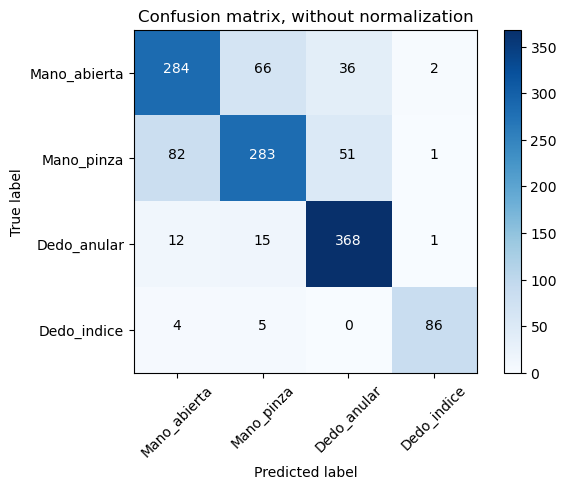

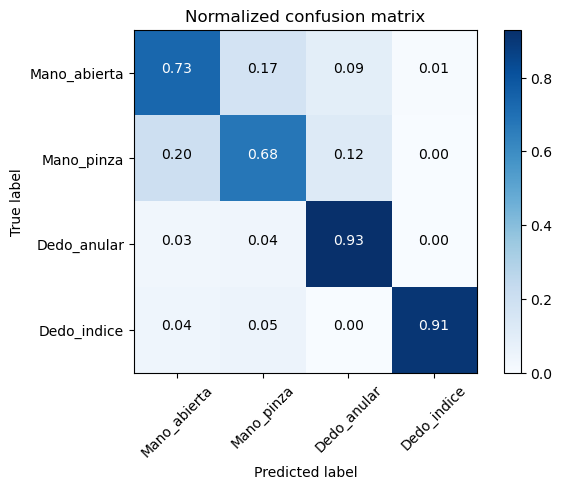

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import pickle

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_pinza['iav'], 
    df_anular['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Aplicar factores de escalamiento para ajustar la relevancia
scaling_factors = {
    "MAV_total": 1.0,
    "VAR_total": 1.0,
    "RMS_total": 1.0,
    "Wav_Leng": 1.0,
    "Dasdv": 1.0,
    "Damv": 1.0,
    "iav": 1.0
}

for feature, factor in scaling_factors.items():
    abs_df[feature] = abs_df[feature] * factor

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_pinza['Mano_pinza'].apply(lambda x: 1),
    df_anular['Dedo_anular'].apply(lambda x: 2),
    df_indice['Dedo_indice'].apply(lambda x: 3),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Guardar el StandardScaler ajustado
with open('standard_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# Convertir las etiquetas en formato one-hot encoding
y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)

# Crear el modelo de red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='softmax'))

# Compilar el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test))

# Hacer predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluar el modelo
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_true, y_pred_classes)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_pinza', 'Dedo_anular', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_pinza', 'Dedo_anular', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# Guardar el modelo entrenado en formato nativo de Keras
model.save('modelo_red_neuronal_reducido.keras')
